
# PRÁCTICA: Comparación KNN vs Regresión Logística vs SVM  
## Dataset: Breast Cancer Wisconsin

**Instrucciones**
- Puedes desarrollar tu código en las celdas que se faciliten. En algunos casos, hay alguna ayuda.
- Si prefieres otra forma de desarrollo también es válida. Completa el trahajo con tus propios comentarios


---
## 0️⃣ Imports y configuración

In [1]:

# Importa lo necesario para:
# - pandas, numpy
# - train_test_split
# - StandardScaler
# - SimpleImputer (si hay NaN)
# - KNeighborsClassifier
# - LogisticRegression
# - SVC
# - métricas: accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
# - matplotlib.pyplot

# Escribe aquí tus imports 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

---
## 1️⃣ Carga y exploración del dataset

In [2]:
# Carga el CSV (ajusta el nombre si es necesario)
df_cancer = pd.read_csv("breat_cancer_wisconsin_dataset.csv")
# Muestra shape y primeras filas
print(df_cancer.shape)
print(df_cancer.head())
# Identifica la columna objetivo (normalmente 'diagnosis')

# Comprueba valores

# Comprueba balanceo de clases


(569, 33)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  

In [3]:
# Mostrar el numero de nulos en las columnas
df_cancer.isna().sum().sort_values(ascending=False)[:2]

Unnamed: 32    569
id               0
dtype: int64


**Pregunta (responder en una frase):**  
- ¿El dataset está balanceado?

- ¿Hay NaN? Si los hay, ¿qué estrategia usarás (drop vs imputación) y por qué?

Hay que hacer drop de esa columna, ya que no aporta ninguna información sobre el cancer. De hecho esa columna, proviene de un error del dataset.


---
## 2️⃣ Limpieza mínima + definición de X e y

In [4]:
# Elimina columnas irrelevantes si existen (típicas: 'id', 'Unnamed: 32', 'Unnamed: 0')
df_cancer.drop(columns=['id', 'Unnamed: 32'], inplace=True)

# Define X e y
X = df_cancer.drop(columns=["diagnosis"])
y = df_cancer["diagnosis"]

# Verifica shapes
print(X.shape)
print(y.shape)

(569, 30)
(569,)


---
## 3️⃣ Train/Test split

In [5]:
# Divide en train y test
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Verifica el resultado
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


---
## 4️⃣ Tratamiento de NaN + Escalado (obligatorio para KNN y SVM)

In [6]:
# Decisiones a tomar si hay NaN,

#       Si han NaN, podremos reemplazar los nulos por la mediana de esa columna, pero si son muchos los valores nulos 
#       en una columna deberemos de quitar la columna, ya que sino nos estariamos inventando la mitad de los datos.

# Si NO hay NaN

#       Si no hay nulos, deberemos de comprobar como tenemos el dataset, ya que para trabajar deberemos de tener numeros y no strings.

# Escala con StandardScaler (fit en train, transform en test)
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

# Verifica que no quedan NaN
df_cancer.isna().sum()[:1]

diagnosis    0
dtype: int64


**Pregunta**  
¿Por qué es obligatorio escalar en KNN y SVM?

    Porque al depender de una distancia como es en este caso, es obligatorio hacerlo, ya que si no lo escalasemos el resultado seria incorrecto


---
## 5️⃣ Modelo 1: KNN (búsqueda de k)

In [ ]:
# Recorre k impares (puedes consultar la teoría)
# Calcula y guarda:
# - accuracy (en test)
# - AUC (en test) usando predict_proba

# Entrenando el modelo de KNN
model_k = KNeighborsClassifier(n_neighbors=19)
model_k.fit(X_train, Y_train)

# Prediciendo datos de KNN
Y_pred_k = model_k.predict(X_test)

# Viendo metricas de KNN
accuracy_k = accuracy_score(Y_test, Y_pred_k)
Y_proba_k = model_k.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

# Calculando AUC para KNN usando predict_proba
auc_k = roc_auc_score(Y_test, Y_proba_k)
print("KNN Accuracy:", accuracy_k)
print("KNN AUC:", auc_k)
# Identifica el mejor k según accuracy y el mejor k según AUC
# El mejor K según accuracy es 9
# El mejor K según AUC es 19

KNN Accuracy: 0.9473684210526315
KNN AUC: 0.9944317065181788


Exception ignored in: <function ResourceTracker.__del__ at 0x7924fff8aa20>
Traceback (most recent call last):
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x78f85608aa20>
Traceback (most recent call last):
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac

---
## 6️⃣ Gráfica: superponer Accuracy y AUC vs k

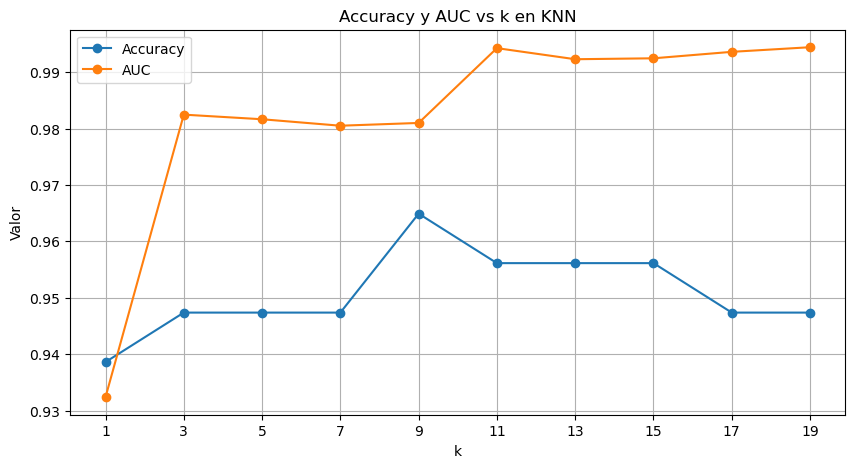

In [8]:
# Representa en el mismo gráfico accuracy y AUC vs k
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
accuracy_values = [0.9385964912280702, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9649122807017544, 0.956140350877193, 0.956140350877193, 0.956140350877193, 0.9473684210526315, 0.9473684210526315]
auc_values = [0.93236016115296429, 0.9824762528660334, 0.9816573861775302, 0.9805109728136259, 0.9810022928267277, 0.9942679331804782, 0.9923026531280708, 0.9924664264657714, 0.9936128398296757, 0.9944317065181788]

plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracy_values, marker='o', label='Accuracy')
plt.plot(k_values, auc_values, marker='o', label='AUC')
plt.title('Accuracy y AUC vs k en KNN')
plt.xlabel('k')
plt.ylabel('Valor')
plt.xticks(k_values)
plt.legend()
plt.grid()
plt.show()



**Pregunta**  
¿Coincide el mejor k según Accuracy con el mejor k según AUC? ¿Por qué podría no coincidir?

    No coincide, porque el accuracy mide el porcentaje de predicciones correctas, y AUC mide la capacidad del modelo de distinguir entre distintas clases.


---
## 7️⃣ Entrena el KNN final (elige un k) + métricas

KNN Accuracy: 0.9649122807017544
KNN Confusion Matrix:
 [[69  2]
 [ 2 41]]
KNN Classification Report:
               precision    recall  f1-score   support

           B       0.97      0.97      0.97        71
           M       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

KNN AUC: 0.9944317065181788


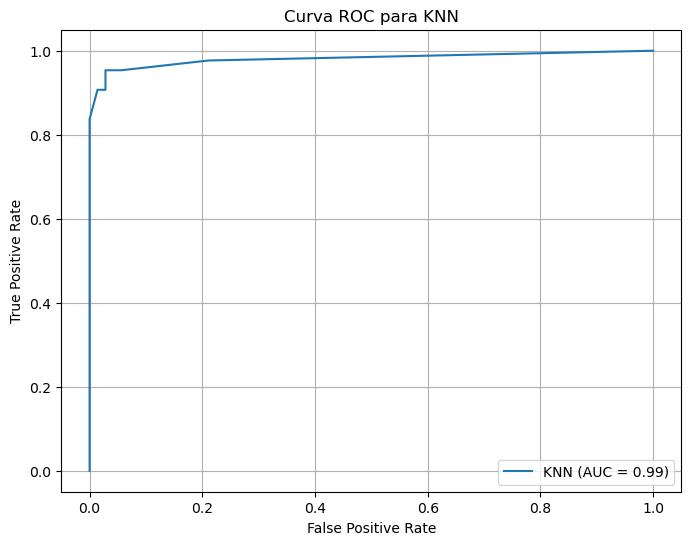

In [9]:

# Elige k final (puede ser best_k_auc o un criterio razonado)
# Usé el que tiene el Accuracy más alto, que es k=9, ya que lo importante del modelo es que sepa predecir bien, asi que prioricé el Accuracy sobre el AUC, aunque ambos son muy buenos.

# Entrena y evalúa:
# - accuracy
# - matriz de confusión
# - classification_report
# - curva ROC + AUC

# Entrenando el modelo de KNN
model_k = KNeighborsClassifier(n_neighbors=9)
model_k.fit(X_train, Y_train)

# Prediciendo datos de KNN
Y_pred_k = model_k.predict(X_test)

# Viendo metricas de KNN
accuracy_k = accuracy_score(Y_test, Y_pred_k)
Y_proba_k = model_k.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

# Matriz de confusión
conf_matrix_k = confusion_matrix(Y_test, Y_pred_k)

# Classification report
class_report_k = classification_report(Y_test, Y_pred_k)

print("KNN Accuracy:", accuracy_k)
print("KNN Confusion Matrix:\n", conf_matrix_k)
print("KNN Classification Report:\n", class_report_k)
print("KNN AUC:", auc_k)

# Curva ROC + AUC
fpr_k, tpr_k, thresholds_k = roc_curve(Y_test, Y_proba_k, pos_label="M")
plt.figure(figsize=(8, 6))
plt.plot(fpr_k, tpr_k, label=f'KNN (AUC = {auc_k:.2f})')
plt.title('Curva ROC para KNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

---
## 8️⃣ Modelo 2: Regresión Logística

Logistic Regression Accuracy: 0.9736842105263158
Logistic Regression Confusion Matrix:
 [[70  1]
 [ 2 41]]
Logistic Regression AUC: 0.99737962659679


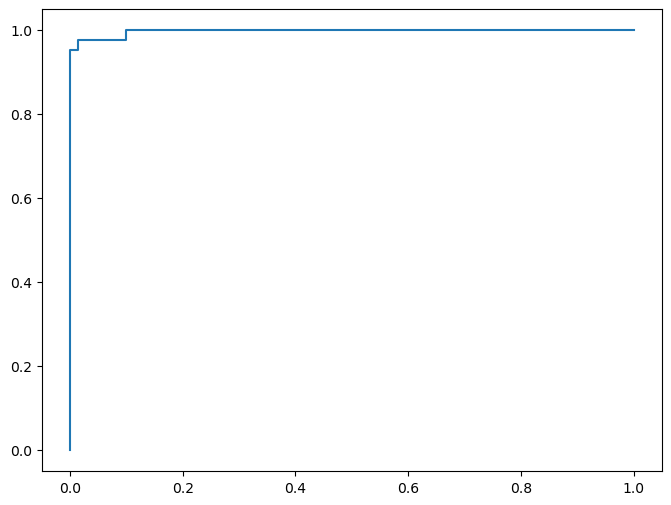

In [10]:
# Entrena LogisticRegression (max_iter suficiente)

# Evalúa:
# - accuracy
# - matriz de confusión
# - AUC
# - curva ROC

# Entrenando el modelo de Logistic Regression
model_lr = LogisticRegression(max_iter=1000, n_jobs=-1)
model_lr.fit(X_train, Y_train)

# Prediciendo datos de Logistic Regression
Y_pred_lr = model_lr.predict(X_test)
Y_proba_lr = model_lr.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

# Matriz de confusión
conf_matrix_lr = confusion_matrix(Y_test, Y_pred_lr)

# AUC
auc_lr = roc_auc_score(Y_test, Y_proba_lr)

# ROC
fpr_lr, tpr_lr, thresholds_lr = roc_curve(Y_test, Y_proba_lr, pos_label="M")

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')

accuracy_lr = accuracy_score(Y_test, Y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)
print("Logistic Regression Confusion Matrix:\n", conf_matrix_lr)
print("Logistic Regression AUC:", auc_lr)

---
## 9️⃣ Modelo 3: SVM

SVM Accuracy: 0.9736842105263158
SVM AUC: 0.99737962659679


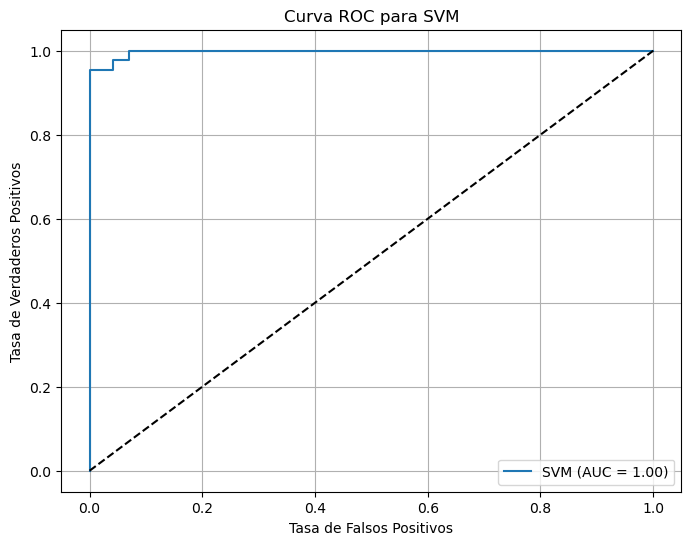

In [ ]:
# Entrena SVM razonadamente
model_svm = SVC(kernel="rbf", probability=True, random_state=42)
model_svm.fit(X_train, Y_train)

# Prediciendo datos de SVM
Y_pred_svm = model_svm.predict(X_test)
Y_proba_svm = model_svm.predict_proba(X_test)[:, 1]

# Viendo metricas de SVM
accuracy_svm = accuracy_score(Y_test, Y_pred_svm)

# AUC para SVM
auc_svm = roc_auc_score(Y_test, Y_proba_svm)

# ROC
fpr_svm, tpr_svm, thresholds_svm = roc_curve(Y_test, Y_proba_svm, pos_label="M")

print("SVM Accuracy:", accuracy_svm)
print("SVM AUC:", auc_svm)
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Línea diagonal para referencia
plt.title('Curva ROC para SVM')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()
plt.grid()
plt.show()

# Evalúa (accuracy + AUC + ROC)

---
## 🔟 Comparación final: ROC superpuestas + tabla

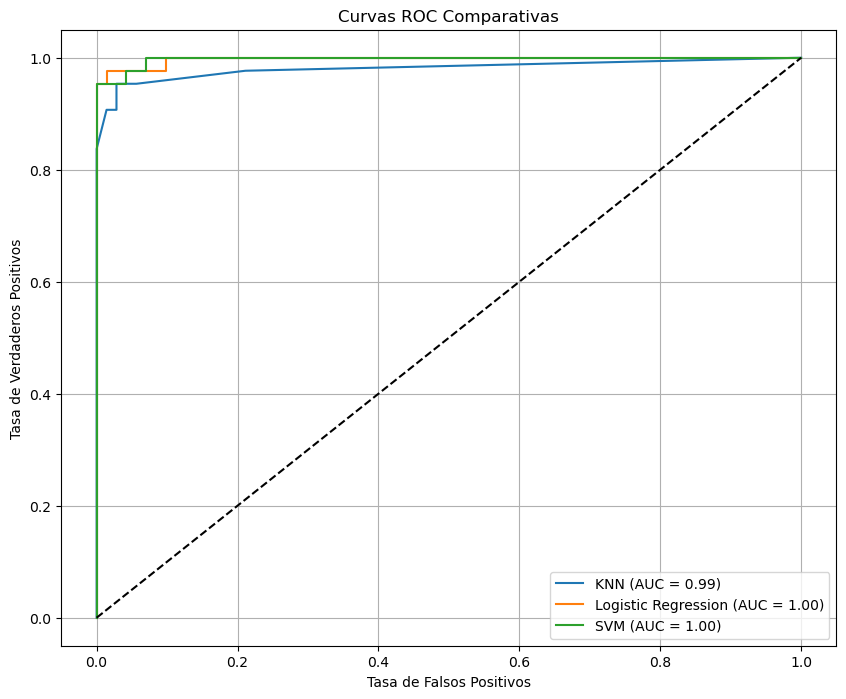

        Modelo  Accuracy      AUC
Reg. Logística  0.973684 0.997380
           SVM  0.973684 0.997380
           KNN  0.964912 0.994432


In [12]:
# Dibuja en el MISMO gráfico las ROC de:
# - KNN final
# - Regresión logística
# - SVM (elige la mejor versión: lineal o RBF)

plt.figure(figsize=(10, 8))
plt.plot(fpr_k, tpr_k, label=f'KNN (AUC = {auc_k:.2f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Línea diagonal para referencia
plt.title('Curvas ROC Comparativas')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()
plt.grid()
plt.show()

# Puedes crear una tabla comparativa

import pandas as pd

resumen = pd.DataFrame({
    'Modelo': ['KNN', 'Reg. Logística', 'SVM'],
    'Accuracy': [accuracy_k, accuracy_lr, accuracy_svm],
    'AUC': [auc_k, auc_lr, auc_svm]
}).sort_values(by='AUC', ascending=False)

print(resumen.to_string(index=False))



---
## 1️⃣1️⃣ Conclusiones

Responde razonadamente:

1. ¿Qué modelo elegirías para este problema y por qué?

    - En este caso escogería regresión logistica (0,973), aparte de por su alta precisión, lo escogería porque el modelo se encarga de calcular probabilidades de "tener o no tener" lo cual es positivo y en el caso de este dataset de datos médicos es un gran punto a favor. En este caso escogería SVM debido a su alto accuracy (0,973) porque el resultado de acierto es muy alto, aunque al igual que KNN, este es más costoso entrenarlo. Igualmente también se podria escoger. Por último, el KNN es otro buen modelo el cual cuenta con un accuracy bastante alto, pero presenta el inconveniente de que es lento de entrenar, y encima el resultado no es el mejor.

2. ¿Qué métrica te parece más relevante en un contexto médico: accuracy o AUC? Justifica tu respuesta.

    - La métrica mas importante es el Accuracy, ya que la finalidad del modelo es identificar correctamente los nuevos datos que lleguen, y sobretodo siendo datos médicos en los cuales es importante no fallar. 

3. Si el dataset fuera 100 veces más grande, ¿cuál de los tres modelos crees que sería menos recomendable y por qué?

    - En el caso de que el dataset fuese 100 veces mas grande, el factor principal para escoger el modelo sería el coste de entrenamiento, el cual en este caso ya medio descarta el KNN, ya que a la hora de predecir es demasiado lento y es muy costoso de entrenar debido a que debe de calcular la distancia entre puntos y para eso no es simple. Si es verdad que el accuracy de SVC es el más alto, en este caso podriamos usar regresión logística, debido a que tiene el mismo accuracy por mucho menos coste de entrenamiento. 

4. ¿Cuál es el modelo más interpretable de los tres?

    - El modelo mas interpretable de los 3 es el de Regresión Logistica, ya que su resultado es una probabilidad entre 0 y 1. Aparte a la hora de representarlo es bastante simple. A diferencia de los demás, ya que KNN te da la distancia entre puntos y SVC muestra los datos en muchas dimensiones y es dificil de observar.
